In [1]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd

code to check if preprocessing pipeline is working correctly.

In [2]:
"""
def preprocess_dataset(df, split_name, max_files=3):
    print(f"Processing {split_name} dataset")

    for i, audio_path in enumerate(df["audio_path"]):
        audio = audio_preprocessing_pipeline(audio_path)

        print(f"{audio_path}")
        print(f"  Shape: {audio.shape}")
        print(f"  Duration (sec): {len(audio)/16000:.2f}")

        if i == max_files - 1:
            break
            
preprocess_dataset(training_protocols, "train")

audio = audio_preprocessing_pipeline(training_protocols["audio_path"].iloc[0])

print(audio.min(), audio.max())

from IPython.display import Audio
Audio(audio, rate=16000)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))
plt.plot(audio)
plt.title("Preprocessed Audio Waveform")
plt.show()
"""

'\ndef preprocess_dataset(df, split_name, max_files=3):\n    print(f"Processing {split_name} dataset")\n\n    for i, audio_path in enumerate(df["audio_path"]):\n        audio = audio_preprocessing_pipeline(audio_path)\n\n        print(f"{audio_path}")\n        print(f"  Shape: {audio.shape}")\n        print(f"  Duration (sec): {len(audio)/16000:.2f}")\n\n        if i == max_files - 1:\n            break\n\npreprocess_dataset(training_protocols, "train")\n\naudio = audio_preprocessing_pipeline(training_protocols["audio_path"].iloc[0])\n\nprint(audio.min(), audio.max())\n\nfrom IPython.display import Audio\nAudio(audio, rate=16000)\n\nimport matplotlib.pyplot as plt\n\nplt.figure(figsize=(10, 3))\nplt.plot(audio)\nplt.title("Preprocessed Audio Waveform")\nplt.show()\n'

## learning to make spectrogrmas.

In [140]:
sample_audio = "file_example_WAV_2MG.wav"
librosa.get_samplerate(sample_audio)

44100

In [141]:
y, sr = librosa.load(sample_audio)
ipd.Audio(sample_audio)
# Does the same thing.
ipd.Audio(y, rate=sr)

In [142]:
#by defalut librosa resamples audio file to 22050
print(sr)

22050


In [143]:
y.shape

(263037,)

In [144]:
FRAME_SIZE = 2048
HOP_SIZE = 512

stft_audio = librosa.stft(y, n_fft=FRAME_SIZE, hop_length=HOP_SIZE)

In [145]:
stft_audio.shape

(1025, 514)

In [146]:
# 1025 are all frequecy bins = half the frame size plus and 1342 are no. of frames.

In [147]:
type(stft_audio[0][0])

numpy.complex64

In [148]:
# calculating the spectogram. to calculate the spectogram we have take mag. of all fourier coff.and square the

In [149]:
Y_scale = np.abs(stft_audio)**2
# noe this is going to be equal to the spetogram

In [150]:
Y_scale.shape

(1025, 514)

In [151]:
type(Y_scale[0][0])

numpy.float32

In [152]:
#these real no. are what we can visualixe on heat map

In [153]:
# visualizing the spectogram

def plot_spectrogram(Y, sr, hop_length, y_axis="linear"):
    plt.figure(figsize=(25,10))
    librosa.display.specshow(Y,
                             sr=sr,
                             hop_length=hop_length,
                             x_axis="time",
                             y_axis=y_axis)
    plt.colorbar(format="%+2.f")

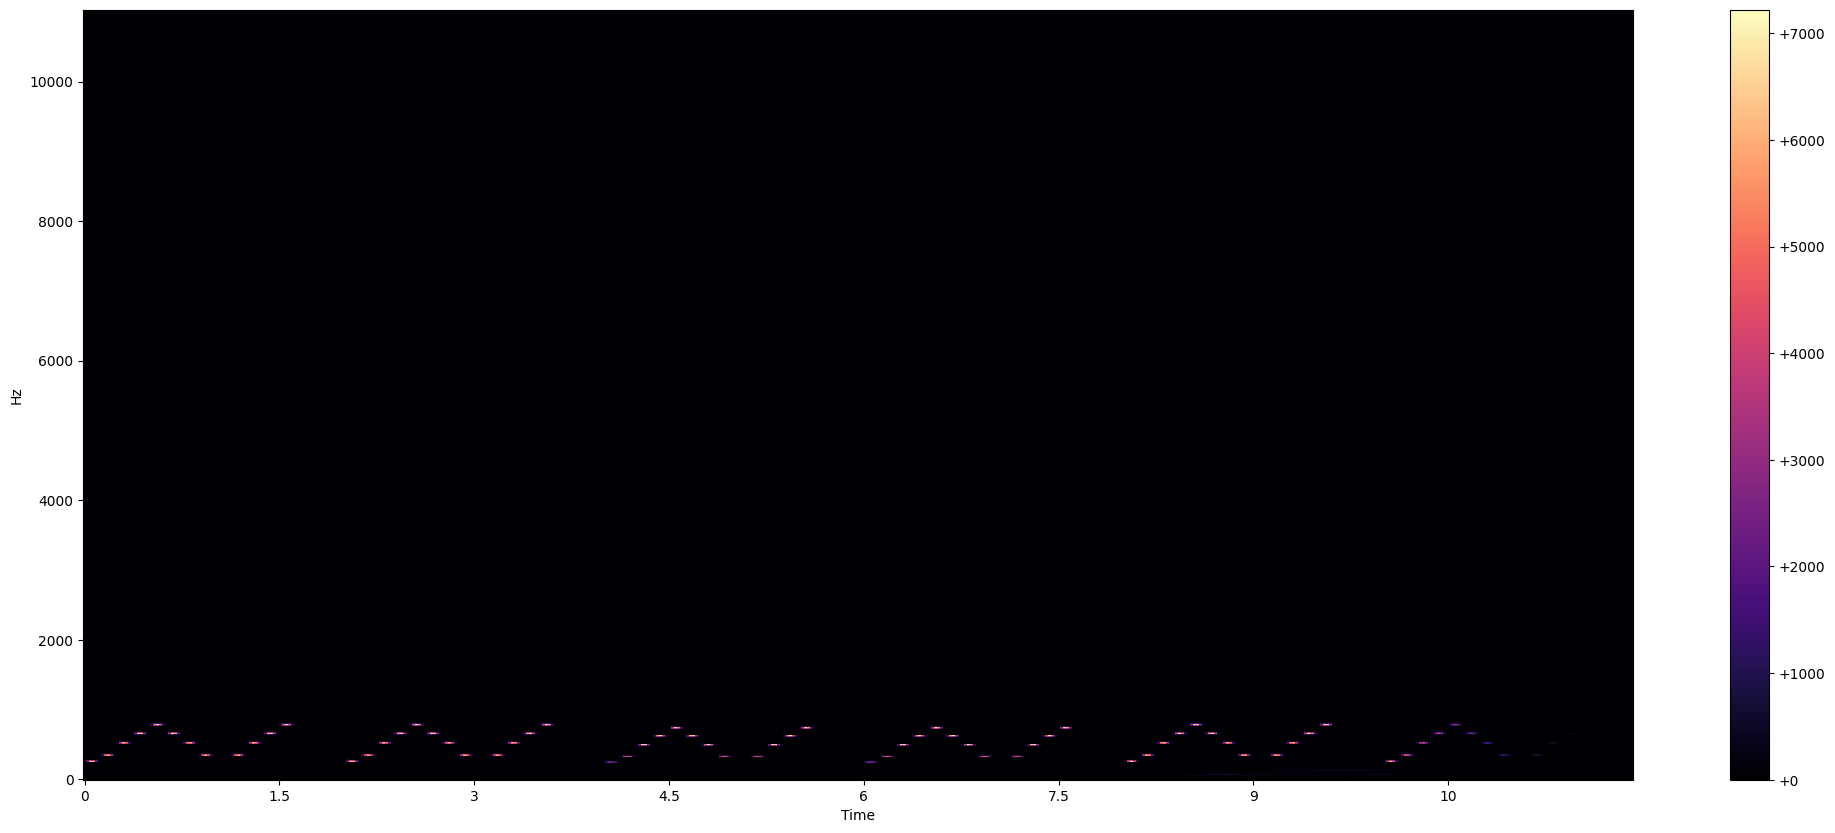

In [154]:
plot_spectrogram(Y_scale, sr, HOP_SIZE)

In [157]:
# above representation is linear representation

# log-amplitude spectrogram

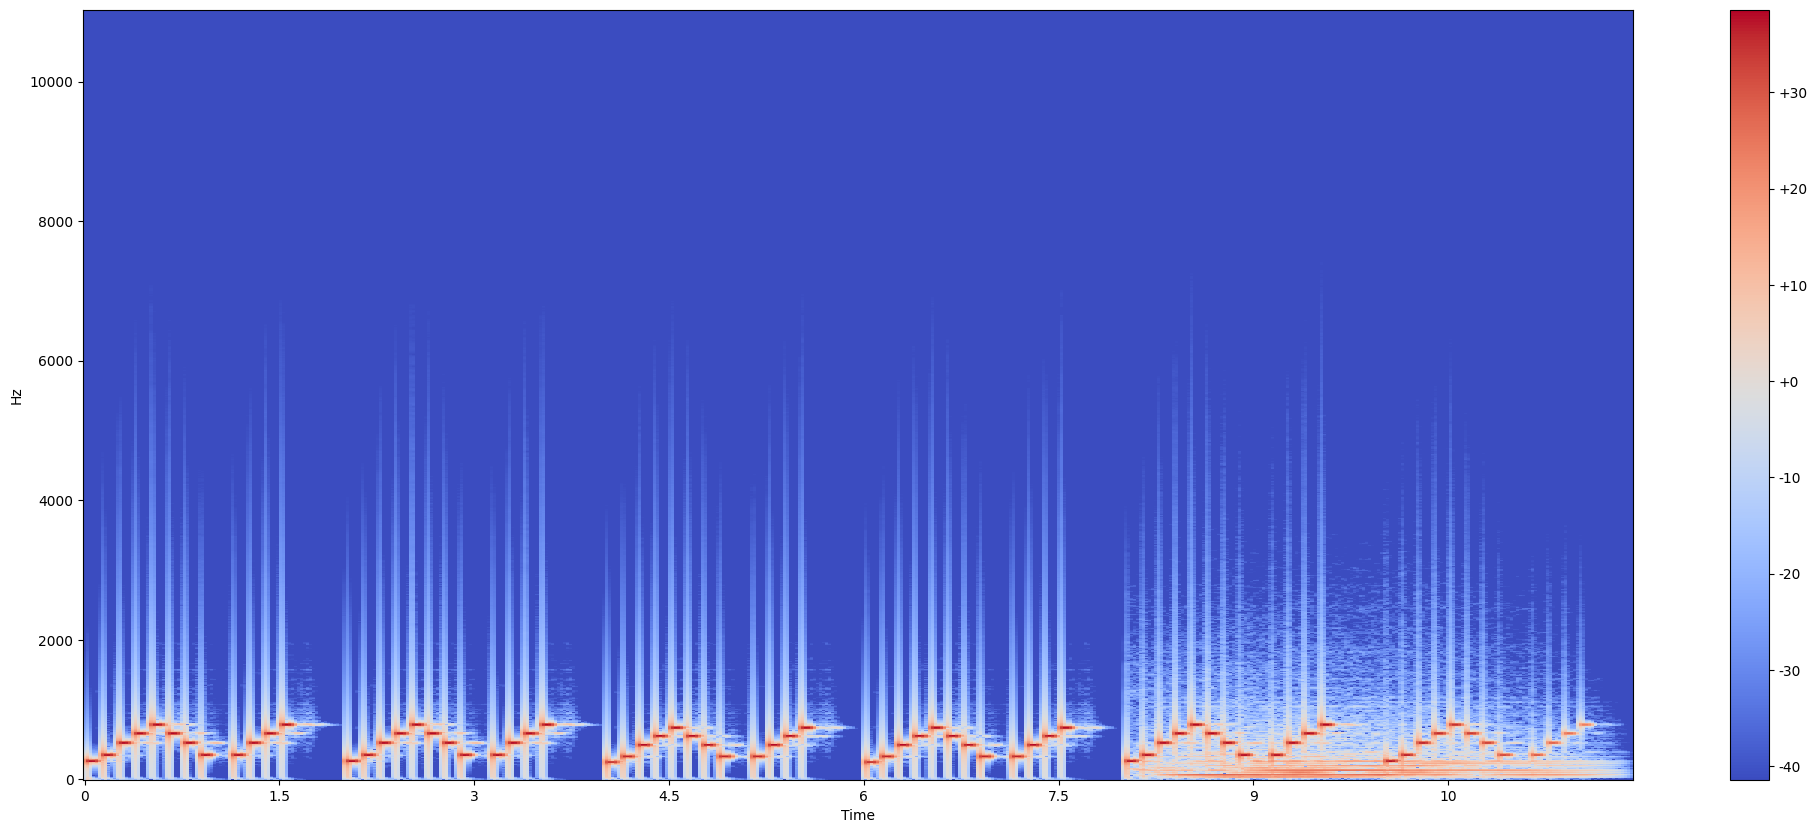

In [158]:
Y_log_scale = librosa.power_to_db(Y_scale)
# this converted power to intensity.
plot_spectrogram(Y_log_scale, sr, HOP_SIZE)

In [164]:
# log_frequency spectogram
# applying log transformation on frequency as well, above we only applieg log trans. to amplitude.

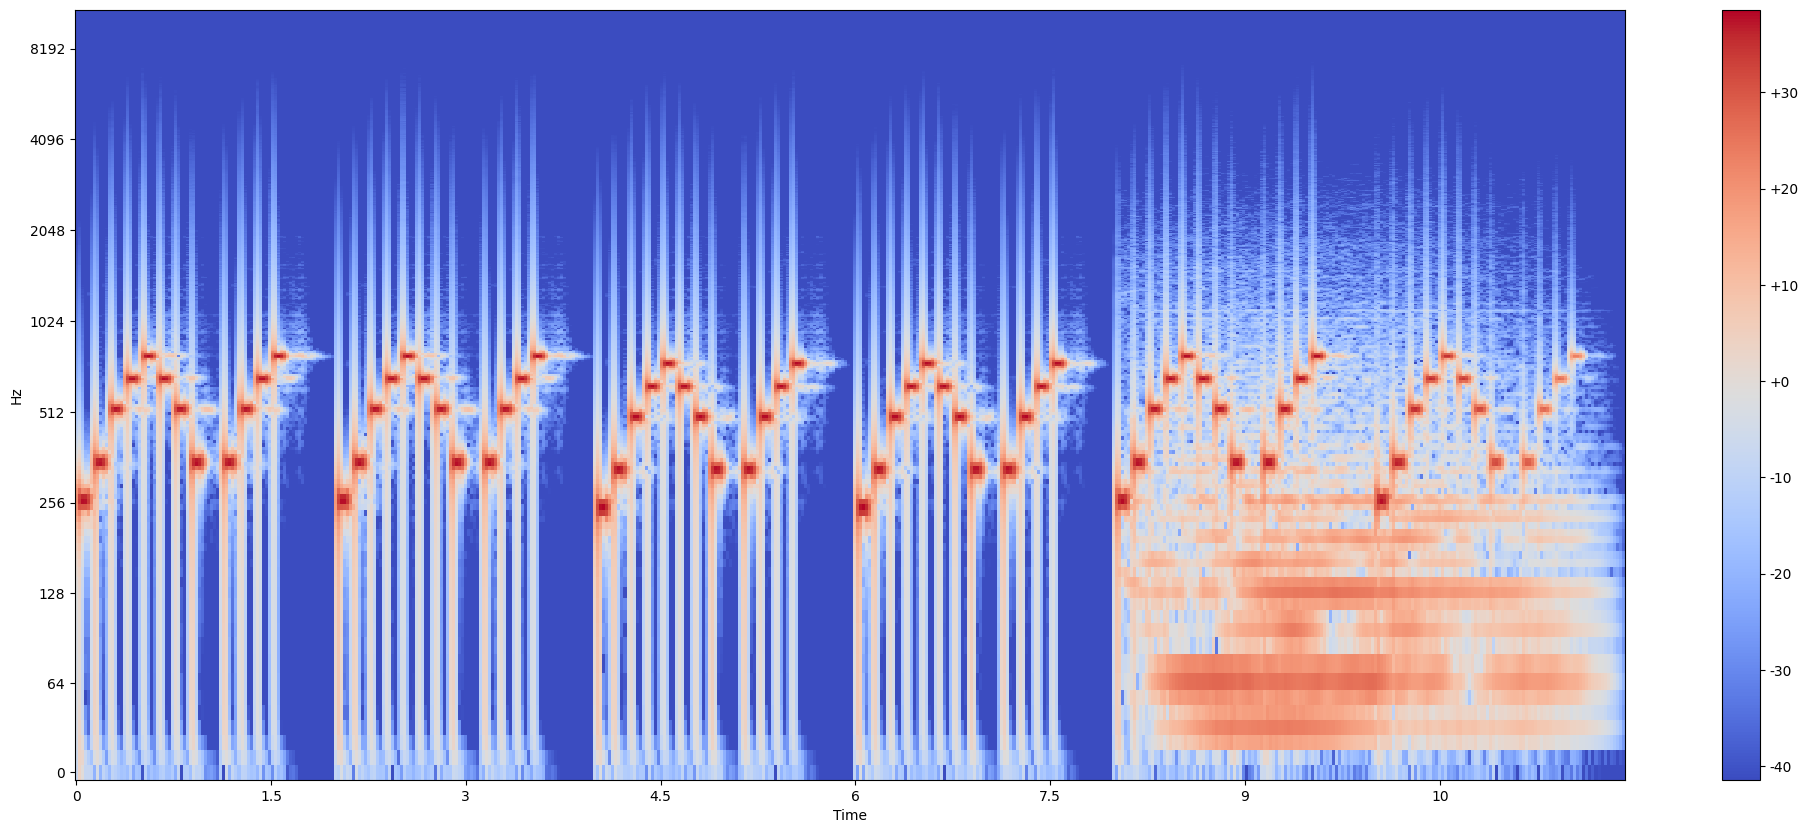

In [165]:
plot_spectrogram(Y_log_scale, sr, HOP_SIZE, y_axis="log")